# The analysis datasets: what series 2, 3 and 4 are allowed to consume

## Scope

Everything before this notebook audits one source at a time. This notebook is the
join, and its output is not a table of counts but the **datasets themselves**:
the rows that carry both a cleavage-environment description and a kinetic
measurement, filtered to conditions under which those two describe the same
enzyme, and written out so that no later notebook has to reassemble them.

Two datasets are produced rather than one, because the analysis needs a control on
its own expansion:

| Dataset | Cleavage environment | Kinetics | Role |
| --- | --- | --- | --- |
| **baseline** | MEROPS matrices of the serum panel | BRENDA, serum EC scope | what the specification asked for |
| **extended** | MEROPS matrices, human datasets | BRENDA, every peptidase EC | what the hypothesis actually needs |

The pair is the point. A result that appears only in the extended dataset is a
result about the expansion, and a result present in both is a result about the
relation.

## What "compatible" means here

A row is admissible only if every one of these holds, and the count lost at each
step is reported:

1. the substrate description yields a **sequence**;
2. the scissile bond is either stated by the construct or treatable as latent, so
   a $P_4 \ldots P_4'$ window exists;
3. the protease has a **human** MEROPS matrix, so the score and the measurement
   describe the same organism;
4. the measurement is on the $k_{cat}/K_M$ scale, directly or by pairing
   $k_{cat}$ with $K_M$ from one publication and protein record;
5. the assay conditions fall inside the policy of `0_11`.

## Inputs and outputs

Inputs: both BRENDA extractions, `data/merops/`, the serum manifest,
`results/0_03_hpa_abundance_per_protease.csv`.

Outputs: `results/0_15_dataset_baseline.csv`,
`results/0_15_dataset_extended.csv`, `results/0_15_assembly_losses.csv`,
`results/0_15_dataset_comparison.csv`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    EventGeometry,
    enumerate_window_scores,
    geometry_from_name,
    load_amino_acid_background,
    load_panel_metadata,
    load_protease_panel,
    masked_score_from_indices,
    parse_substrate,
    reporter_window_indices,
    resolvable_subsites,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
# The two datasets this notebook emits, and the kinetic extraction behind each.
DATASETS = {
    "baseline": common.BRENDA_KINETICS,
    "extended": common.BRENDA_ALL_PEPTIDASES,
}
# Only human peptidases. Dataset 34 is the full human set, 35 its serum subset;
# every other MEROPS dataset is a pathogen.
HUMAN_MEROPS_DATASETS = (34, 35)
# A quenched substrate shorter than this cannot carry an informative window.
MIN_FRET_LENGTH = 6
# Condition policy, imported so that changing it in one place changes it here too.
TEMPERATURE_POLICY_C = common.TEMPERATURE_POLICY_C
PH_POLICY = common.PH_POLICY
DROP_MUTANT_ENZYMES = common.EXCLUDE_MUTANT_ENZYMES
MIN_SUBSTRATES_PER_PROTEASE = common.MIN_SUBSTRATES_PER_PROTEASE
SEED = common.SEED

# Free-text condition patterns; see 0_11 for why the temperature pattern is strict.
PH_PATTERN = re.compile(r"pH\s*([0-9]+(?:\.[0-9]+)?)", re.IGNORECASE)
TEMPERATURE_PATTERN = re.compile(
    r"(?<![A-Z])(?<![A-Za-z0-9])(\d{1,2}(?:\.\d)?)\s*(?:°\s*C|degrees?\s*C|deg\s*C)\b", re.IGNORECASE
)
MUTANT_PATTERN = re.compile(r"\bmutant\b|\bvariant\b", re.IGNORECASE)

In [3]:
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
manifest = common.load_serum_manifest()
serum_codes = set(manifest.loc[manifest["include_in_hydrolysis_model"], "merops_code"])
names = {
    entry["code"]: entry["name"]
    for entry in load_panel_metadata(list(HUMAN_MEROPS_DATASETS), merops_root=common.MEROPS_ROOT)
}

## One human matrix per code, from whichever human dataset holds the most evidence
matrices: dict[str, tuple[np.ndarray, int, int]] = {}
for dataset_id in HUMAN_MEROPS_DATASETS:
    panel = load_protease_panel(dataset_id, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
    counts = {
        entry["code"]: entry["n_cleavages"]
        for entry in load_panel_metadata(dataset_id, merops_root=common.MEROPS_ROOT)
    }
    stack = panel.matrices.numpy().astype(np.float64)
    for position, code in enumerate(panel.codes):
        n_cleavages = int(counts.get(code, 0))
        if code not in matrices or n_cleavages > matrices[code][2]:
            matrices[code] = (stack[position], dataset_id, n_cleavages)

geometries = {
    row["merops_code"]: geometry_from_name(row["merops_name"])
    for _, row in manifest.iterrows()
}
print(f"human MEROPS codes with a matrix: {len(matrices)}")
print(f"serum panel codes: {len(serum_codes)}")

human MEROPS codes with a matrix: 390
serum panel codes: 54


## Assembling one dataset

The same function builds both, so the two differ in their input extraction and in
nothing else. Every filtering step records what it removed, because the losses are
the quantity `0_14` reports and a silent filter would make that table wrong.

In [4]:
def assemble(kinetics_path: Path, label: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Build one analysis dataset and the record of what assembling it discarded.

    :param kinetics_path: Parquet holding one BRENDA extraction.
    :param label: Name of the dataset, carried into the output.
    :return: Tuple of the dataset and its loss record.
    """

    losses = []
    kinetics = pd.read_parquet(kinetics_path).query("value_kind == 'numeric'").copy()
    losses.append({"step": "numeric BRENDA entries", "rows": len(kinetics)})

    ## 1. Conditions, parsed from free text and filtered by the shared policy
    comment = kinetics["comment_raw"].fillna("")
    kinetics["ph"] = comment.str.extract(PH_PATTERN)[0].astype(float)
    kinetics["temperature_c"] = comment.str.extract(TEMPERATURE_PATTERN)[0].astype(float)
    kinetics["is_mutant"] = comment.str.contains(MUTANT_PATTERN)
    before = len(kinetics)
    kinetics = common.apply_condition_policy(
        kinetics, temperature_policy=TEMPERATURE_POLICY_C, ph_policy=PH_POLICY
    )
    losses.append({"step": "after the assay-condition policy", "rows": len(kinetics)})
    if DROP_MUTANT_ENZYMES:
        kinetics = kinetics[~kinetics["is_mutant"]]
        losses.append({"step": "after removing mutant enzymes", "rows": len(kinetics)})

    ## 2. Substrate descriptions that yield a sequence and a window
    parses = [parse_substrate(text) for text in kinetics["substrate_raw"]]
    kinetics["substrate_sequence"] = [parse.sequence for parse in parses]
    kinetics["is_fret"] = [parse.is_fret for parse in parses]
    reporter_subsites = np.array([resolvable_subsites(parse) for parse in parses])
    kinetics["window_convention"] = np.where(
        reporter_subsites > 0,
        "reporter",
        np.where(
            kinetics["is_fret"] & (kinetics["substrate_sequence"].str.len() >= MIN_FRET_LENGTH),
            "quenched",
            "unusable",
        ),
    )
    kinetics = kinetics.query("window_convention != 'unusable'").copy()
    losses.append({"step": "with a usable substrate window", "rows": len(kinetics)})

    ## 3. The efficiency label: direct, plus kcat over KM paired within one report
    key = ["merops_codes", "substrate_raw", "substrate_sequence", "window_convention", "pmids", "protein_ids"]
    direct = (
        kinetics.query("parameter_type == 'kcat_km_value'")
        .groupby(key, dropna=False)["value_numeric"].median()
        .reset_index().rename(columns={"value_numeric": "efficiency"})
    )
    turnover = kinetics.query("parameter_type == 'turnover_number'").groupby(key, dropna=False)["value_numeric"].median().rename("kcat")
    michaelis = kinetics.query("parameter_type == 'km_value'").groupby(key, dropna=False)["value_numeric"].median().rename("km")
    paired = pd.concat([turnover, michaelis], axis=1, join="inner").reset_index()
    paired["efficiency"] = paired["kcat"] / paired["km"]
    direct["label_origin"] = "reported"
    paired["label_origin"] = "paired"
    observations = pd.concat(
        [direct[[*key, "efficiency", "label_origin"]], paired[[*key, "efficiency", "label_origin"]]],
        ignore_index=True,
    )
    observations = observations[observations["efficiency"] > 0].copy()
    observations["log10_kcat_over_km"] = np.log10(observations["efficiency"] * 1e3)
    losses.append({"step": "on the kcat/KM scale", "rows": len(observations)})

    labels = (
        observations.groupby(["merops_codes", "substrate_raw", "substrate_sequence", "window_convention"], dropna=False)
        .agg(
            log10_kcat_over_km=("log10_kcat_over_km", "median"),
            n_measurements=("log10_kcat_over_km", "size"),
            label_spread=("log10_kcat_over_km", lambda values: float(values.max() - values.min())),
            paired_share=("label_origin", lambda values: float((values == "paired").mean())),
        )
        .reset_index()
    )
    losses.append({"step": "distinct (protease set, substrate) labels", "rows": len(labels)})

    ## 4. The window score, from the human matrix of each candidate code
    rows = []
    for _, record in labels.iterrows():
        for code in str(record["merops_codes"]).split(";"):
            code = code.strip()
            if code not in matrices:
                continue
            matrix, dataset_id, n_cleavages = matrices[code]
            sequence = record["substrate_sequence"]
            geometry = geometries.get(code, EventGeometry.ENDOPEPTIDASE)

            if record["window_convention"] == "reporter":
                score, observed = masked_score_from_indices(
                    sequence,
                    reporter_window_indices(parse_substrate(record["substrate_raw"])),
                    matrix,
                    background=human_background,
                )
                implied_bond, n_candidates = np.nan, 1
            else:
                scores, observed_per_bond, admissible = enumerate_window_scores(
                    sequence, matrix, geometry, background=human_background
                )
                if not admissible.any():
                    continue
                best = int(np.argmax(np.where(admissible, scores, -np.inf)))
                score, observed = float(scores[best]), int(observed_per_bond[best])
                implied_bond, n_candidates = best, int(admissible.sum())

            rows.append(
                {
                    "dataset": label,
                    "merops_code": code,
                    "merops_name": names.get(code, ""),
                    "in_serum_panel": code in serum_codes,
                    "merops_dataset_id": dataset_id,
                    "merops_cleavages": n_cleavages,
                    "event_geometry": geometry.value,
                    "substrate_raw": record["substrate_raw"],
                    "substrate_sequence": sequence,
                    "window_convention": record["window_convention"],
                    "sequence_length": len(sequence),
                    "n_observed_subsites": observed,
                    "n_candidate_bonds": n_candidates,
                    "implied_bond": implied_bond,
                    "merops_score": score,
                    "log10_kcat_over_km": record["log10_kcat_over_km"],
                    "n_measurements": record["n_measurements"],
                    "label_spread": record["label_spread"],
                    "paired_share": record["paired_share"],
                    "shares_measurements_with_n_codes": len(str(record["merops_codes"]).split(";")),
                }
            )

    dataset = pd.DataFrame(rows)
    losses.append({"step": "rows with a human matrix and a score", "rows": len(dataset)})

    ## 5. Enough evidence per protease to support a within-protease statistic
    counts = dataset.groupby("merops_code")["substrate_raw"].nunique()
    keep = counts[counts >= MIN_SUBSTRATES_PER_PROTEASE].index
    dataset = dataset[dataset["merops_code"].isin(keep)].copy()
    losses.append(
        {"step": f"proteases with at least {MIN_SUBSTRATES_PER_PROTEASE} substrates", "rows": len(dataset)}
    )

    loss_frame = pd.DataFrame(losses)
    loss_frame["dataset"] = label
    loss_frame["retained_share"] = loss_frame["rows"] / loss_frame["rows"].iloc[0]
    return dataset, loss_frame


assembled, loss_records = {}, []
for name, path in DATASETS.items():
    dataset, losses = assemble(path, name)
    assembled[name] = dataset
    loss_records.append(losses)
    print(f"\n--- {name} ---")
    print(losses.to_string(index=False))

losses_all = pd.concat(loss_records, ignore_index=True)


--- baseline ---
                                     step  rows  dataset  retained_share
                   numeric BRENDA entries  3773 baseline        1.000000
         after the assay-condition policy  3752 baseline        0.994434
           with a usable substrate window  1229 baseline        0.325735
                     on the kcat/KM scale   375 baseline        0.099390
distinct (protease set, substrate) labels   290 baseline        0.076862
     rows with a human matrix and a score   338 baseline        0.089584
     proteases with at least 3 substrates   330 baseline        0.087464



--- extended ---
                                     step  rows  dataset  retained_share
                   numeric BRENDA entries  8308 extended        1.000000
         after the assay-condition policy  7619 extended        0.917068
           with a usable substrate window  2961 extended        0.356403
                     on the kcat/KM scale   917 extended        0.110376
distinct (protease set, substrate) labels   617 extended        0.074266
     rows with a human matrix and a score   770 extended        0.092682
     proteases with at least 3 substrates   746 extended        0.089793


### Reading the figure

The funnel from every numeric BRENDA entry to the rows that reach the regression,
one line per dataset. The steepest drop is the step that limits the analysis; a
reader who wants more data should attack that step and not another.

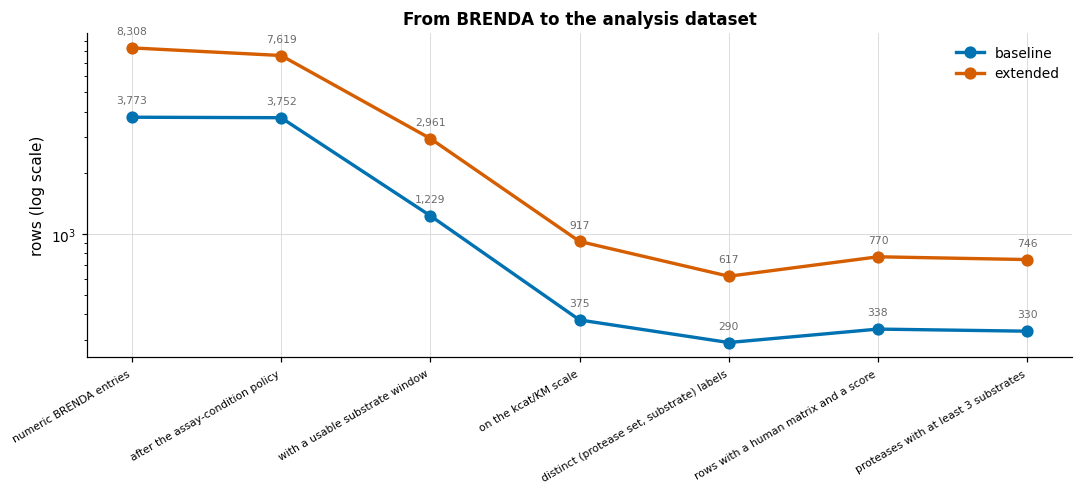

In [5]:
fig, ax = plt.subplots(figsize=(10.0, 4.6))
for name, colour in zip(DATASETS, common.CATEGORICAL_COLORS):
    subset = losses_all[losses_all["dataset"] == name]
    ax.plot(range(len(subset)), subset["rows"], marker="o", markersize=7, linewidth=2.2, color=colour, label=name)
    for index, row in enumerate(subset.itertuples()):
        ax.annotate(f"{row.rows:,}", (index, row.rows), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=7, color=common.NEUTRAL)
ax.set_yscale("log")
ax.set_xticks(range(len(losses_all[losses_all["dataset"] == "extended"])))
ax.set_xticklabels(losses_all[losses_all["dataset"] == "extended"]["step"], rotation=30, ha="right", fontsize=7)
ax.set_ylabel("rows (log scale)")
ax.set_title("From BRENDA to the analysis dataset")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## What the two datasets contain, and what they share

The comparison is the answer to "how much does the expansion add": not in rows,
which is the easy number, but in proteases carrying enough evidence to support a
statistic, and in how far the two agree on the proteases they share.

In [6]:
comparison_rows = []
for name, dataset in assembled.items():
    comparison_rows.append(
        {
            "dataset": name,
            "rows": len(dataset),
            "proteases": dataset["merops_code"].nunique(),
            "substrates": dataset["substrate_raw"].nunique(),
            "serum_panel_proteases": dataset.loc[dataset["in_serum_panel"], "merops_code"].nunique(),
            "median_substrates_per_protease": float(dataset.groupby("merops_code")["substrate_raw"].nunique().median()),
            "median_observed_subsites": float(dataset["n_observed_subsites"].median()),
            "reporter_share": float((dataset["window_convention"] == "reporter").mean()),
            "paired_label_share": float(dataset["paired_share"].mean()),
        }
    )
comparison = pd.DataFrame(comparison_rows)
print(comparison.round(3).to_string(index=False))

shared = set(assembled["baseline"]["merops_code"]) & set(assembled["extended"]["merops_code"])
only_extended = set(assembled["extended"]["merops_code"]) - set(assembled["baseline"]["merops_code"])
print(f"\nproteases in both datasets: {len(shared)}")
print(f"proteases only in the extended dataset: {len(only_extended)}")

## On the shared proteases, do the two datasets give the same label?
merged = assembled["baseline"].merge(
    assembled["extended"], on=["merops_code", "substrate_raw"], suffixes=("_baseline", "_extended")
)
if len(merged):
    identical = np.isclose(merged["log10_kcat_over_km_baseline"], merged["log10_kcat_over_km_extended"])
    print(f"rows present in both: {len(merged)}, identical label: {int(identical.sum())} ({identical.mean():.1%})")

 dataset  rows  proteases  substrates  serum_panel_proteases  median_substrates_per_protease  median_observed_subsites  reporter_share  paired_label_share
baseline   330         17         249                     17                            11.0                       5.0           0.455               0.701
extended   746         58         524                     19                             8.0                       4.0           0.637               0.704

proteases in both datasets: 17
proteases only in the extended dataset: 41
rows present in both: 330, identical label: 330 (100.0%)


### Reading the figure

Per protease, the substrates available in each dataset. Points on the diagonal are
proteases the expansion did not touch; points above it gained evidence; points on
the vertical axis exist only because of the expansion. The colour separates the
serum panel from the wider human peptidase set, which is the boundary the
specification drew and the hypothesis does not respect.

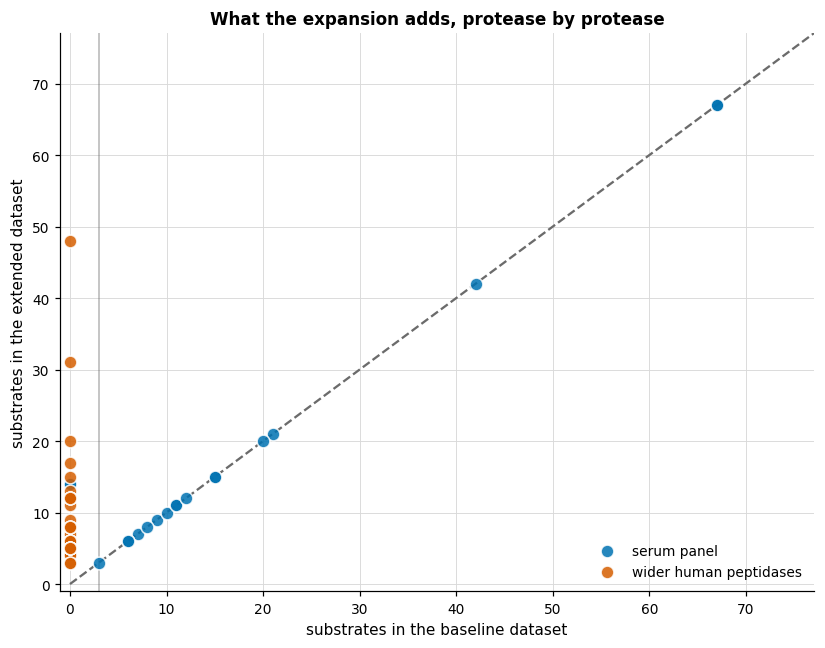

In [7]:
counts = (
    pd.concat(
        [
            dataset.groupby("merops_code")["substrate_raw"].nunique().rename(name)
            for name, dataset in assembled.items()
        ],
        axis=1,
    )
    .fillna(0)
    .reset_index()
)
serum_flag = (
    assembled["extended"].drop_duplicates("merops_code").set_index("merops_code")["in_serum_panel"]
)
counts["in_serum_panel"] = counts["merops_code"].map(serum_flag).fillna(False)

fig, ax = plt.subplots(figsize=(7.6, 6.0))
for flag, colour, label in (
    (True, common.CATEGORICAL_COLORS[0], "serum panel"),
    (False, common.CATEGORICAL_COLORS[1], "wider human peptidases"),
):
    subset = counts[counts["in_serum_panel"] == flag]
    ax.scatter(subset["baseline"], subset["extended"], s=70, color=colour, alpha=0.85, edgecolor="white", linewidth=1.0, zorder=3, label=label)
limit = max(counts["extended"].max(), counts["baseline"].max()) * 1.15
ax.plot([0, limit], [0, limit], color=common.NEUTRAL, linestyle="--", linewidth=1.5)
ax.axvline(MIN_SUBSTRATES_PER_PROTEASE, color=common.NEUTRAL, linewidth=1.0, alpha=0.5)
ax.set_xlim(-1, limit)
ax.set_ylim(-1, limit)
ax.set_xlabel("substrates in the baseline dataset")
ax.set_ylabel("substrates in the extended dataset")
ax.set_title("What the expansion adds, protease by protease")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [8]:
common.save_result(assembled["baseline"], "0_15_dataset_baseline.csv")
common.save_result(assembled["extended"], "0_15_dataset_extended.csv")
common.save_result(losses_all, "0_15_assembly_losses.csv")
common.save_result(comparison, "0_15_dataset_comparison.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_15_dataset_comparison.csv')

## What this establishes

**Series 0 ends with two files, not with a verdict.** `0_15_dataset_baseline.csv`
and `0_15_dataset_extended.csv` hold every row that carries both a scored
cleavage window and a catalytic efficiency, under assay conditions in which the
two describe the same enzyme. Series 2 consumes them directly; nothing downstream
reassembles the join, so a change to the condition policy or to the minimum
evidence per protease takes effect everywhere by re-running this notebook alone.

**The losses are where the analysis actually lives.** The funnel shows which step
costs the most, and it is not the condition policy. A reader who wants a larger
dataset has to attack the step that loses most, which the figure names.

**The pair is a control, not a redundancy.** The baseline is what the calibration
specification asked for and the extended is what the hypothesis needs, since a
question about whether a matrix predicts its own enzyme's kinetics has no reason
to respect a serum boundary. Carrying both is what makes the cost of the expansion
measurable rather than assumed, and the per-protease figure shows exactly which
enzymes the expansion brought in.